# Dataset feasibility spike: IEEE-CIS and PaySim vs system requirements

**Question:** can a public transaction dataset support the system being built (streamed
scoring at a 1,000 transactions-per-second target, behavioural features, analyst-readable
explanations, a label-feedback loop, drift monitoring), or does it need a synthetic
generator? Two candidates are staged in `data/raw/`: IEEE-CIS (real card transactions) and
PaySim (synthetic mobile money). The criteria:

| # | Requirement | Concrete test |
|---|---|---|
| 1 | Persistent customer identity | Customer key exists? Txns per key (median, p90) |
| 2 | Real, orderable time | Continuous timestamps replayable as a stream |
| 3 | Interpretable features | Analyst-readable SHAP (SHapley Additive exPlanations) values? Fails if features anonymized |
| 4 | Beneficiary identity | Counterparty key in schema (beneficiary novelty, authorised push payment fraud) |
| 5 | Label semantics | Can a 30-60 day label maturity delay be simulated from the data? |
| 6 | Typology structure | Stolen card / account takeover (ATO) / APP (authorised push payment) scam distinguishable? |
| 7 | Drift over time | Enough span and distribution change to test monitoring |

**Verdict rule:** a dataset must pass criteria 1-5 to serve as the core data; 6 and 7 are
desirable. If either candidate passes 1-5, real data is the core. If both fail several, we
build the generator and keep the strongest candidate as a benchmark.

## IEEE-CIS

We test IEEE-CIS first: it is the strongest candidate (real transactions at realistic
scale), so if anything passes 1-5, it is this, and a pass would end the question early.
Criterion 1 goes first because it gates the rest; the system's backbone features are
per-customer velocity windows, and without a persistent customer key there is nothing to
compute them over. IEEE-CIS documents no customer id, so the best available proxy is the
card fingerprint (the six card fields plus billing address), measured for history depth:
median and p90 transactions per key, and the share of volume on keys deep enough for
windowed features. The 300+ anonymized columns are left alone unless a criterion forces
the issue.

In [1]:
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 50)
RAW = Path.cwd().parent / "data" / "raw" if Path.cwd().name == "experiments" else Path("data/raw")
assert RAW.exists(), RAW

# evidence per (dataset, criterion), rendered as the decision table at the end
evidence: dict[tuple[str, int], str] = {}

ieee_path = RAW / "ieee-cis" / "labeled_transactions.csv"
ieee_all_cols = pd.read_csv(ieee_path, nrows=0).columns.tolist()
ieee_cols = [
    "TransactionID", "isFraud", "TransactionDT", "TransactionAmt", "ProductCD",
    "card1", "card2", "card3", "card4", "card5", "card6",
    "addr1", "P_emaildomain", "R_emaildomain",
]
ieee = pd.read_csv(ieee_path, usecols=ieee_cols)
print(f"{len(ieee):,} rows, {len(ieee_all_cols)} total cols, fraud rate {ieee.isFraud.mean():.4%}")

590,540 rows, 394 total cols, fraud rate 3.4990%


In [2]:
# Criterion 1: persistent customer identity.
# No customer id in the schema; proxy = card fingerprint (card1..card6 + addr1).
key = (
    ieee[["card1", "card2", "card3", "card4", "card5", "card6", "addr1"]]
    .astype("string").fillna("NA").agg("|".join, axis=1)
)
per_key = key.value_counts()
print(f"proxy keys: {per_key.size:,}")
print(f"txns per key: median {per_key.median():.0f}, p90 {per_key.quantile(0.9):.0f}, max {per_key.max():,}")
print(f"span: {(ieee.TransactionDT.max() - ieee.TransactionDT.min()) / 86400:.0f} days")
print(f"share of txns on keys with >=20 txns: {per_key[per_key >= 20].sum() / len(ieee):.1%}")
evidence[("IEEE", 1)] = (
    f"No customer id; card-fingerprint proxy: median {per_key.median():.0f} txns/key, "
    f"p90 {per_key.quantile(0.9):.0f}, {per_key[per_key >= 20].sum() / len(ieee):.0%} of txns on keys >=20"
)

proxy keys: 43,018
txns per key: median 2, p90 21, max 9,900
span: 182 days
share of txns on keys with >=20 txns: 77.3%


The typical key is nearly empty (median 2 transactions, p90 21), which was not the picture
we expected from card data; what saves it is concentration, with 77% of all transaction
volume sitting on keys of 20 or more transactions. That would be enough history for windowed
velocity features over most of the stream. But one number undermines confidence in the whole
measurement: a maximum of 9,900 transactions on a single key is implausibly high for one
customer over the 182-day span (about 54 per day), which suggests several customers colliding on
one proxy value. The 77% figure is only as good as the proxy, and the proxy is untested, so
criterion 1 cannot be scored yet. Before moving on we validate the proxy directly: find
something in the data whose behaviour should be consistent within one real customer, and
check whether it is consistent within these keys.

### Validating the proxy key

The competition host's public hints say the anonymized C-columns are counts and the
D-columns are timedeltas. Both imply per-entity structure that can be tested without knowing
the exact meaning of any column: a cumulative count per entity must be non-decreasing over
time within one entity, and a "days since some fixed anchor" timedelta minus the transaction
day must be constant within one entity. If the proxy key is the true entity, keys should
pass both tests; if several customers share a key, they should fail. The tests run on
medium-depth keys only (20-40 transactions, a few hundred keys), and no attempt is made to
decode what the columns actually mean.

In [3]:
extra = pd.read_csv(ieee_path, usecols=["TransactionID", "TransactionDT", "C13", "D1"])
val = ieee.join(extra.set_index("TransactionID"), on="TransactionID", rsuffix="_x")
val["daynum"] = val.TransactionDT / 86400

# shape check first: do the columns even look like a count and a day-scaled timedelta?
print(f"C13: integer-valued {(extra.C13.dropna() % 1 == 0).all()}, range {extra.C13.min():.0f}-{extra.C13.max():.0f}")
print(f"D1:  integer-valued {(extra.D1.dropna() % 1 == 0).all()}, range {extra.D1.min():.0f}-{extra.D1.max():.0f} (day-scaled)")

mod_keys = per_key[(per_key >= 20) & (per_key <= 40)].index[:200]

# test A: cumulative count C13 non-decreasing within key
grow = tot_a = 0
for k in mod_keys[:80]:
    g = val[key == k].sort_values("TransactionDT").dropna(subset=["C13"])
    if len(g) < 8:
        continue
    tot_a += 1
    grow += g.C13.is_monotonic_increasing
print(f"C13 non-decreasing within proxy key: {grow}/{tot_a}")

# test B: D1 minus transaction day constant within key
ok = tot_b = 0
for k in mod_keys:
    g = val[key == k].dropna(subset=["D1"])
    if len(g) < 10:
        continue
    tot_b += 1
    ok += (g.D1 - g.daynum).round(0).nunique() <= 2
print(f"D1 minus day constant within proxy key: {ok}/{tot_b}")

C13: integer-valued True, range 0-2918
D1:  integer-valued True, range 0-640 (day-scaled)
C13 non-decreasing within proxy key: 0/80
D1 minus day constant within proxy key: 1/200


We expected the key to mostly hold, since it uses all six card fields plus address. The
result is the opposite, and unambiguous: essentially no proxy key behaves like a single
entity (0/80 keys have a non-decreasing count, 1/200 a stable timedelta anchor). Note what
failed: the shapes behaved exactly as the host hints said (C13 integer-valued in 0-2,918,
count-like; D1 integer in 0-640, day-scaled), so the tests were valid; it is the grouping that failed. The columns track
some hidden true entity, presumably the real card, and the fingerprint lumps several of them
together.

Criterion 1 is therefore partial at best, and the 77% headline above is inflated by
collisions to an unknown degree; the evidence entry is amended below. Two things carry
forward. Velocity features built on this proxy would mix customers' histories, quietly
corrupting the exact features this system depends on. And as a side effect, the validation
confirmed recoverable group-level semantics (counts, timedeltas) in the anonymized columns,
which becomes relevant when criterion 3 asks about interpretability.

In [4]:
# propagate the finding: amend the criterion-1 evidence recorded two cells up
evidence[("IEEE", 1)] += (
    "; validation FAILED (C13 monotone 0/80, D1 anchor 1/200): proxy over-groups customers, "
    "77% figure inflated by collisions"
)

### Criterion 2: real, orderable time

The system replays data as a live stream and trains on temporal splits, so time must be
absolute, continuous, and dense enough to be meaningful at streaming rates. `TransactionDT`
is documented only as "timedelta from a given reference datetime"; we measure total span,
the inter-arrival gap distribution, and the mean rate against the 1,000
transactions-per-second (TPS) target.

In [5]:
dt = ieee.TransactionDT.sort_values()
span_days = (dt.iloc[-1] - dt.iloc[0]) / 86400
gaps = dt.diff().dropna()
print(f"span: {span_days:.0f} days; inter-arrival median {gaps.median():.0f}s, "
      f"p99 {gaps.quantile(0.99):.0f}s, max {gaps.max():,.0f}s")
print(f"mean rate: {len(ieee) / (span_days * 86400):.2f} txn/s")
evidence[("IEEE", 2)] = (
    f"Relative seconds only (no absolute date); {span_days:.0f}-day span, largest gap "
    f"{gaps.max() / 3600:.1f}h; mean {len(ieee) / (span_days * 86400):.2f} txn/s vs 1k TPS target"
)

span: 182 days; inter-arrival median 13s, p99 237s, max 4,138s
mean rate: 0.04 txn/s


Ordering is solid: 182 continuous days, median 13 seconds between transactions, worst gap
about 69 minutes, so temporal train/validation splits are fully supported. Two problems
remain, one per system need. On the calendar side, timestamps are seconds from an
undisclosed epoch, so weekday and holiday effects are guesswork and nothing external can be
joined by date. On the streaming side, 0.04 transactions per second against a 1,000 TPS
target means a replay would need roughly 25,000x time compression, at which point the
arrival process being load-tested is the compression artifact rather than the data's
behaviour. Partial: usable for offline modelling, not viable as the live demo stream.
Whatever the remaining criteria say, the streaming path already needs generated traffic; the
open question narrows to whether IEEE-CIS can be the training core.

### Criterion 3: interpretable features

The system must show an analyst why a transaction scored high (SHAP top-5), which requires
features a human can read. First the anonymization is measured directly: how many columns
are masked (V/C/D/M/id_* naming) versus named. Then, since the proxy validation already
showed the masked columns carry testable structure, the identity side-table is checked for
readability (coverage and top values only, no attempt to decode the V-columns).

In [6]:
import re

anon = [c for c in ieee_all_cols if re.fullmatch(r"[VCDM]\d+|id_\d+", c)]
named = [c for c in ieee_all_cols if c not in anon]
print(f"{len(anon)}/{len(ieee_all_cols)} main-table columns anonymized (V/C/D/M/id_*)")
print("named:", named)

iden = pd.read_csv(RAW / "ieee-cis" / "labeled_identity.csv")
print(f"\nidentity table: {len(iden):,} rows, joins to {len(iden) / len(ieee):.0%} of transactions")
for c in ["id_12", "id_15", "id_23", "id_30", "id_31", "id_33", "DeviceType", "DeviceInfo"]:
    s = iden[c]
    top = {k: int(v) for k, v in s.dropna().astype(str).value_counts().head(3).items()}
    print(f"{c:11s} nonnull={s.notna().mean():5.1%} top={top}")

377/394 main-table columns anonymized (V/C/D/M/id_*)
named: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain']

identity table: 144,233 rows, joins to 24% of transactions
id_12       nonnull=100.0% top={'NotFound': 123025, 'Found': 21208}
id_15       nonnull=97.7% top={'Found': 67728, 'New': 61612, 'Unknown': 11645}
id_23       nonnull= 3.6% top={'IP_PROXY:TRANSPARENT': 3489, 'IP_PROXY:ANONYMOUS': 1071, 'IP_PROXY:HIDDEN': 609}
id_30       nonnull=53.8% top={'Windows 10': 21155, 'Windows 7': 13110, 'iOS 11.2.1': 3722}
id_31       nonnull=97.3% top={'chrome 63.0': 22000, 'mobile safari 11.0': 13423, 'mobile safari generic': 11474}
id_33       nonnull=50.8% top={'1920x1080': 16874, '1366x768': 8605, '1334x750': 6447}
DeviceType  nonnull=97.6% top={'desktop': 85165, 'mobile': 55645}
DeviceInfo  nonnull=82.3% top={'Windows': 47722, 'iOS Device

A split verdict that the raw count alone would have missed. The main table is 96% masked,
and of its 17 named columns only amount, product code and email domains describe the
transaction itself; a SHAP output of "V258 drove the score" is useless to an analyst. The
identity table, however, is barely anonymized at all: operating system, browser, screen
resolution, proxy type and Found/New account flags sit there verbatim, exactly the
device-fingerprint vocabulary real fraud operations use, though it joins to only 24% of
transactions and non-randomly. Combined with the proxy-validation finding that the sampled
C and D columns behave as a count and a timedelta, honest group-level explanations are possible
("a count feature, a recency feature and a device signal drove this score"). What is not
possible is the per-column story ("third card use at this merchant in 24 hours") the analyst
dashboard is meant to show. Partial: better than the 96% figure suggests, worse than the
system needs. The V-columns stay undecoded; even full success on them could not add
beneficiary or label fields, which is where the remaining criteria go next.

In [7]:
evidence[("IEEE", 3)] = (
    "377/394 cols masked, but identity table readable verbatim (OS/browser/screen/proxy/"
    "Found-New, 24% coverage) and C/D group semantics (C13, D1) confirmed by the proxy-validation "
    "tests; V1-V339 left undecoded. Partial: group-level SHAP possible, per-column analyst "
    "text is not"
)

### Criteria 4, 5, 6: beneficiary identity, label semantics, typology structure

These three are schema questions (the field either exists or it does not), so they share one
cell. For the beneficiary, the only recipient-shaped field is `R_emaildomain`; we measure
its coverage and cardinality. For label semantics, the question is whether any report or
chargeback date exists from which a 30-60 day maturity delay could be simulated. For
typology, the nearest candidate is `ProductCD`; we check whether it segments fraud rate and
whether that amounts to fraud types. Card datasets are published from the issuer's
viewpoint, which has no reason to include counterparties or report timelines, so all three
are expected thin to absent.

In [8]:
# 4: recipient-shaped fields
r_cov = ieee.R_emaildomain.notna().mean()
print(f"R_emaildomain coverage {r_cov:.1%}, nunique {ieee.R_emaildomain.nunique()}, "
      f"top {({k: int(v) for k, v in ieee.R_emaildomain.value_counts().head(3).items()})}")
evidence[("IEEE", 4)] = (
    f"No beneficiary id; R_emaildomain ({r_cov:.0%} coverage, {ieee.R_emaildomain.nunique()} domains) "
    "is a mail provider, not a counterparty; beneficiary-novelty impossible"
)
# 5: label fields in the schema
label_like = [c for c in ieee_all_cols if "fraud" in c.lower() or "date" in c.lower()]
print("label-related columns:", label_like)
evidence[("IEEE", 5)] = "Binary isFraud only, no report/chargeback date; 30-60d maturity must be invented"
# 6: does ProductCD amount to typology?
print(ieee.groupby("ProductCD").isFraud.agg(["count", "mean"]))
evidence[("IEEE", 6)] = "No typology labels; ProductCD segments risk by product, not by fraud type"

R_emaildomain coverage 23.2%, nunique 60, top {'gmail.com': 57147, 'hotmail.com': 27509, 'anonymous.com': 20529}
label-related columns: ['isFraud']
            count      mean
ProductCD                  
C           68519  0.116873
H           33024  0.047662
R           37699  0.037826
S           11628  0.058996
W          439670  0.020399


As expected, and the way they fail matters. These are absent fields, not degraded ones, a
different failure class from criteria 1-3 where inspection could partially rehabilitate the
data. "gmail.com" at 23% coverage cannot be a novel beneficiary. `isFraud` is the schema's
entire label vocabulary, so a maturity delay would be invented rather than simulated. And
ProductCD's sixfold fraud-rate spread (11.7% for C vs 2.0% for W) is real risk segmentation
but says nothing about how the fraud happened: stolen card and account takeover are
indistinguishable, and APP-style push payments do not exist in card data at all. No further
inspection is warranted, because inspection cannot create fields.

IEEE-CIS therefore fails criteria 4, 5 and 6 outright, three of the five must-pass criteria,
and its candidacy as core data is over whatever criterion 7 says. Criterion 7 is still
measured, both to complete the table and because drift bears on a different use
(monitoring), not on the core-data question.

### Criterion 7: drift over time

The drift-monitoring part of the system needs data whose distributions actually move. We
split the 182 days into halves and compare daily volume, fraud rate, and one covariate
(product mix), plotting the daily series to see shape rather than just endpoints.

early window: days 20-25 rate 0.0167 at 6,042 txns/day; days 50+ rate 0.0378
fraud rate halves: 0.0357 vs 0.0364
ProductCD 'W' share halves: 0.70 vs 0.80; daily volume 3516 vs 2974


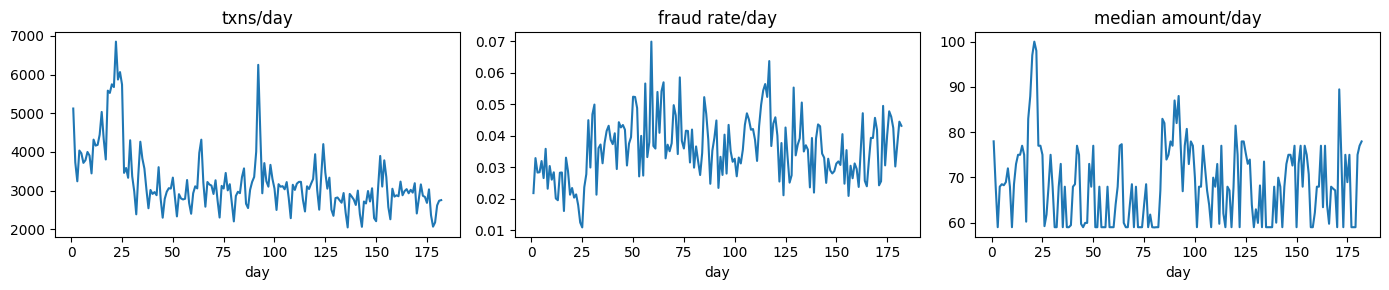

In [9]:
import matplotlib.pyplot as plt

ieee["day"] = (ieee.TransactionDT // 86400).astype(int)
daily = ieee.groupby("day").agg(n=("isFraud", "size"), fraud_rate=("isFraud", "mean"),
                                amt=("TransactionAmt", "median"))
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
daily.n.plot(ax=axes[0], title="txns/day")
daily.fraud_rate.plot(ax=axes[1], title="fraud rate/day")
daily.amt.plot(ax=axes[2], title="median amount/day")
plt.tight_layout()

half = len(daily) // 2
fr1, fr2 = daily.fraud_rate.iloc[:half].mean(), daily.fraud_rate.iloc[half:].mean()
first, second = ieee[ieee.day <= ieee.day.max() // 2], ieee[ieee.day > ieee.day.max() // 2]
w1, w2 = first.ProductCD.eq("W").mean(), second.ProductCD.eq("W").mean()
v1, v2 = first.groupby("day").size().mean(), second.groupby("day").size().mean()
print(f"early window: days 20-25 rate {daily.fraud_rate.iloc[20:25].mean():.4f} at {daily.n.iloc[20:25].mean():,.0f} txns/day; days 50+ rate {daily.fraud_rate.iloc[50:].mean():.4f}")
print(f"fraud rate halves: {fr1:.4f} vs {fr2:.4f}")
print(f"ProductCD 'W' share halves: {w1:.2f} vs {w2:.2f}; daily volume {v1:.0f} vs {v2:.0f}")
evidence[("IEEE", 7)] = (
    f"182 days; fraud rate flat ({fr1:.4f} -> {fr2:.4f}) but genuine covariate drift "
    f"(W share {w1:.2f} -> {w2:.2f}, daily volume {(v2 / v1 - 1):.0%}); usable for monitoring tests"
)

We expected fraud-rate drift (fraud waves coming and going); the data says otherwise.
Between halves the fraud rate barely moves (3.57% vs 3.64%), so there is no sustained label
drift. The early wobble in the daily plot is a dilution artifact
rather than a fraud wave: a volume surge peaking around days 20-25 (about 6,000 transactions
per day against a typical 3,000) coincides with the rate dipping to 1.7%, and once volume
settles the rate holds around 3.7-4% for the rest of the span. The genuine
long-run movement is covariate: product mix shifts hard (W share 0.70 to 0.80) and daily
volume trends down 15%, visible as trends in the plots rather than endpoint noise. For this
project that is the more valuable kind: feature distributions moving while the label rate
holds is precisely the silent-degradation scenario a drift monitor exists to catch, and it
is real drift, which a home-built generator could only fake. Criterion 7 passes, the first
clean pass, and the first result arguing for keeping IEEE-CIS in the project even though it
cannot be the core: a credible benchmark and a real-drift test case.

## PaySim

IEEE-CIS failed on entity persistence and the absent fields, and PaySim's schema advertises
exactly those: explicit customer ids (`nameOrig`) and counterparty ids (`nameDest`). So its
claimed strengths are tested first, criteria 1, 2 and 4 in one pass (identity depth, time
granularity via `step`, counterparty reuse). If those hold, PaySim is a serious candidate
and earns detailed treatment; if not, the remaining criteria only need to complete the
decision table. On 6.3m rows this stays at value counts and simple aggregates.

In [10]:
paysim = pd.read_csv(RAW / "paysim" / "transactions.csv")
print(f"{len(paysim):,} rows, fraud rate {paysim.isFraud.mean():.4%}")

# 1: customer identity depth
per_orig = paysim.nameOrig.value_counts()
print(f"nameOrig: {per_orig.size:,} unique; txns/customer median {per_orig.median():.0f}, "
      f"p90 {per_orig.quantile(0.9):.0f}, max {per_orig.max()}")
evidence[("PaySim", 1)] = (
    f"nameOrig exists but median {per_orig.median():.0f} txn/customer (max {per_orig.max()}); "
    "identities not persistent, velocity features impossible"
)
# 2: time granularity
print(f"step: {paysim.step.min()}-{paysim.step.max()} (hours), {paysim.step.nunique()} distinct")
evidence[("PaySim", 2)] = (
    f"Integer hour buckets only ({paysim.step.max()} steps); no intra-hour ordering, "
    "not replayable as a realistic stream"
)
# 4: counterparty reuse
per_dest = paysim.nameDest.value_counts()
print(f"nameDest: {per_dest.size:,} unique; median {per_dest.median():.0f} txns/dest")
evidence[("PaySim", 4)] = (
    f"nameDest key exists but {per_dest.size:,} counterparties at median "
    f"{per_dest.median():.0f} txn each; beneficiary 'novelty' trivially always-novel"
)

6,362,620 rows, fraud rate 0.1291%
nameOrig: 6,353,307 unique; txns/customer median 1, p90 1, max 3
step: 1-743 (hours), 743 distinct
nameDest: 2,722,362 unique; median 1 txns/dest


The advertised strengths do not survive contact with the data. 6.35m customer ids across
6.36m transactions (median 1, p90 1, max 3) means the simulator mints a fresh customer for
nearly every row; there is no behavioural history at all, no velocity windows, no amount
z-scores, no usual pattern to deviate from. The counterparty side is the bigger
disappointment: `nameDest` is exactly the key IEEE-CIS lacked, but with 2.7m destinations at
median 1 transaction each, every payment is to a "new" beneficiary and novelty carries zero
information. A key that exists but never repeats is as useless as no key. Time confirms the
documentation: 743 hourly buckets, orderable only at hour granularity. Three fatal results
in one cell; PaySim now fails 1, 2 and 4 of the must-pass five, so the remaining criteria
are checked to complete the table rather than investigated in depth.

### PaySim, remaining criteria

Columns are named by construction, so criterion 3 should pass trivially; the usable feature
count is still measured rather than eyeballed. For criterion 5 the questions are whether any
report-date field exists and whether `isFlaggedFraud` is the hardcoded threshold its
documentation describes (flag TRANSFERs over 200,000): a checkable claim, so it is checked
rather than trusted. Criterion 6 asks whether fraud has typology structure or one scripted
pattern, and criterion 7 whether the simulated month drifts, checked with the same halves
comparison used for IEEE-CIS.

ids ['nameOrig', 'nameDest'] | labels ['isFraud', 'isFlaggedFraud']
usable feature columns (7): ['step', 'type', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
date/report-like columns: []
isFlaggedFraud=1: 16 rows; documented rule (TRANSFER & >200k) matches 409,110 rows; flagged outside rule: 0
fraud txns flagged: 16 of 8,213
            count   sum      mean
type                             
CASH_IN   1399284     0  0.000000
CASH_OUT  2237500  4116  0.001840
DEBIT       41432     0  0.000000
PAYMENT   2151495     0  0.000000
TRANSFER   532909  4097  0.007688
txns/step halves: 14168 vs 2974
fraud txns/step halves: 11.2 vs 10.9
fraud rate halves: 0.0789% vs 0.3677%
steps with fraud rate == 100%: 131 in first half, 189 in second half


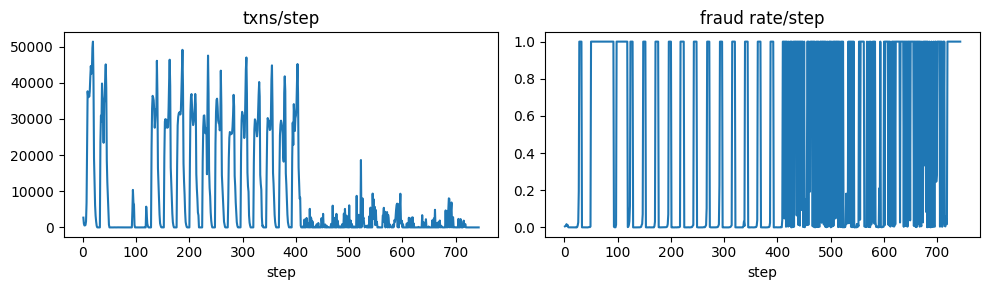

In [11]:
# 3: schema readability + usable feature width (counted, not eyeballed)
id_cols = [c for c in paysim.columns if paysim[c].dtype == object and paysim[c].nunique() > 1000]
label_cols = [c for c in paysim.columns if set(paysim[c].unique()) <= {0, 1}]
feat_cols = [c for c in paysim.columns if c not in id_cols + label_cols]
print(f"ids {id_cols} | labels {label_cols}")
print(f"usable feature columns ({len(feat_cols)}): {feat_cols}")
evidence[("PaySim", 3)] = (
    f"All columns named; {len(feat_cols)} usable feature columns (step, type, amount, "
    "four balances); readable but shallow"
)
# 5: any report/date field? and does isFlaggedFraud behave as documented?
date_like = [c for c in paysim.columns if re.search(r"date|report|charge|time", c, re.I)]
print("date/report-like columns:", date_like)
flagged = paysim.isFlaggedFraud == 1
rule = (paysim.type == "TRANSFER") & (paysim.amount > 200_000)
print(f"isFlaggedFraud=1: {flagged.sum():,} rows; documented rule (TRANSFER & >200k) matches "
      f"{rule.sum():,} rows; flagged outside rule: {(flagged & ~rule).sum():,}")
print(f"fraud txns flagged: {(flagged & paysim.isFraud.eq(1)).sum()} of {paysim.isFraud.sum():,}")
evidence[("PaySim", 5)] = (
    f"Binary isFraud, no report/date field; isFlaggedFraud fires on {flagged.sum()} of "
    f"{rule.sum():,} rows matching its own documented rule and covers {int((flagged & paysim.isFraud.eq(1)).sum())} "
    f"of {paysim.isFraud.sum():,} fraud txns; not a usable second label"
)
# 6: fraud by transaction type
print(paysim.groupby("type").isFraud.agg(["count", "sum", "mean"]))
evidence[("PaySim", 6)] = "Fraud only in TRANSFER/CASH_OUT: one scripted drain pattern, no typology structure"
# 7: halves comparison + step series
by_step = paysim.groupby("step").agg(n=("isFraud", "size"), fr=("isFraud", "mean"))
half_step = paysim.step.max() // 2
n1, n2 = by_step.n.iloc[:half_step].mean(), by_step.n.iloc[half_step:].mean()
f1 = paysim[paysim.step <= half_step].isFraud
f2 = paysim[paysim.step > half_step].isFraud
print(f"txns/step halves: {n1:.0f} vs {n2:.0f}")
print(f"fraud txns/step halves: {f1.sum() / half_step:.1f} vs {f2.sum() / (paysim.step.max() - half_step):.1f}")
print(f"fraud rate halves: {f1.mean():.4%} vs {f2.mean():.4%}")
print(f"steps with fraud rate == 100%: {(by_step.fr.iloc[:half_step] == 1).sum()} in first half, "
      f"{(by_step.fr.iloc[half_step:] == 1).sum()} in second half")
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
by_step.n.plot(ax=axes[0], title="txns/step")
by_step.fr.plot(ax=axes[1], title="fraud rate/step")
plt.tight_layout()

Criteria 3 and 6 came out as anticipated: a readable but shallow schema (7 usable feature
columns once ids and labels are excluded), and fraud existing only in TRANSFER and CASH_OUT
because the simulator scripts exactly one drain pattern.

Criterion 5 held its verdict but not its story. No report-date field exists, as expected,
but `isFlaggedFraud` is not the hardcoded threshold the documentation describes: 409,110
transactions match the documented rule (TRANSFER over 200,000) and only 16 of them carry the
flag, all fraudulent, selected by some additional undocumented condition. Covering 16 of
8,213 fraud transactions, it is useless as a second label under either description, so the
criterion fails regardless; the point of the test is that a documentation claim about the
data failed the cheapest possible check against the data itself.

Criterion 7 did not come out as anticipated either. We assumed a simulation would be
stationary; instead, legitimate volume collapses by about 80% halfway through the simulated
month (14,168 to 2,974 transactions per step) while fraud keeps being injected at a constant
11 or so transactions per step, so the fraud rate "drifts" from 0.08% to 0.37% purely
because the denominator dies. The plots make it worse than the halves numbers suggest:
volume runs in daily bursts with dead hours between them, and during dead hours the injected
fraud is the only traffic, so the fraud rate per step saturates at 100% (131 steps in the
first half, 189 in the collapsed second half). A drift monitor pointed at this would fire on
a simulator artifact, not on anything resembling a changing fraud landscape, so the
criterion fails just as surely as stationarity would have failed it.

Beyond settling PaySim (6 of 7 failed), two lessons outlive the dataset. Fraud injection
decoupled from the legitimate baseline is a detectable synthetic signature, at its extreme
producing hours where every transaction is fraud; any generator this project builds must
couple fraud incidence to baseline activity, or it will carry the same fingerprint. And
dataset documentation is a hypothesis, not a fact: every documented claim this notebook
relies on gets tested against the data before it is used.

In [12]:
# record criterion 7 from the finding above (not the pre-run expectation)
evidence[("PaySim", 7)] = (
    "Non-stationary as an artifact: legit volume collapses ~80% mid-simulation under constant "
    "~11 fraud txns/step, so fraud-rate 'drift' (0.08% -> 0.37%) is a denominator effect, "
    "not monitorable drift"
)

## Results table and verdict

The evidence accumulated above, rendered in full. No new analysis enters from here on; the
verdict below only applies the rule fixed at the top.

In [13]:
criteria = {
    1: "Persistent customer identity", 2: "Real, orderable time", 3: "Interpretable features",
    4: "Beneficiary identity", 5: "Label semantics", 6: "Typology structure", 7: "Drift over time",
}
assert all((ds, i) in evidence for ds in ("IEEE", "PaySim") for i in criteria), "criterion left unscored"
pd.set_option("display.max_colwidth", None)
table = pd.DataFrame(
    {ds: {criteria[i]: evidence[(ds, i)] for i in criteria} for ds in ("IEEE", "PaySim")}
)
table

,IEEE,PaySim
Persistent customer identity,"No customer id; card-fingerprint proxy: median 2 txns/key, p90 21, 77% of txns on keys >=20; validation FAILED (C13 monotone 0/80, D1 anchor 1/200): proxy over-groups customers, 77% figure inflated by collisions","nameOrig exists but median 1 txn/customer (max 3); identities not persistent, velocity features impossible"
"Real, orderable time","Relative seconds only (no absolute date); 182-day span, largest gap 1.1h; mean 0.04 txn/s vs 1k TPS target","Integer hour buckets only (743 steps); no intra-hour ordering, not replayable as a realistic stream"
Interpretable features,"377/394 cols masked, but identity table readable verbatim (OS/browser/screen/proxy/Found-New, 24% coverage) and C/D group semantics (C13, D1) confirmed by the proxy-validation tests; V1-V339 left undecoded. Partial: group-level SHAP possible, per-column analyst text is not","All columns named; 7 usable feature columns (step, type, amount, four balances); readable but shallow"
Beneficiary identity,"No beneficiary id; R_emaildomain (23% coverage, 60 domains) is a mail provider, not a counterparty; beneficiary-novelty impossible","nameDest key exists but 2,722,362 counterparties at median 1 txn each; beneficiary 'novelty' trivially always-novel"
Label semantics,"Binary isFraud only, no report/chargeback date; 30-60d maturity must be invented","Binary isFraud, no report/date field; isFlaggedFraud fires on 16 of 409,110 rows matching its own documented rule and covers 16 of 8,213 fraud txns; not a usable second label"
Typology structure,"No typology labels; ProductCD segments risk by product, not by fraud type","Fraud only in TRANSFER/CASH_OUT: one scripted drain pattern, no typology structure"
Drift over time,"182 days; fraud rate flat (0.0357 -> 0.0364) but genuine covariate drift (W share 0.70 -> 0.80, daily volume -15%); usable for monitoring tests","Non-stationary as an artifact: legit volume collapses ~80% mid-simulation under constant ~11 fraud txns/step, so fraud-rate 'drift' (0.08% -> 0.37%) is a denominator effect, not monitorable drift"


### Market scan: is there a third dataset that passes? (2026-07-13)

Before accepting the verdict, we scanned for any other public dataset passing criteria 1-5
(AI-search sweep, then primary-source verification of each candidate's schema).

| Dataset | Real? | Fails on | Evidence |
|---|---|---|---|
| AMLNet (Zenodo 16736515) | synthetic | typologies are AML (anti-money-laundering: structuring/layering/integration) not fraud; hour-bucket time; CC BY-NC license | 17-col schema verified at Zenodo: step/hour fields, `laundering_typology`, bare `isFraud` |
| Czech PKDD'99 (Berka) | **real** (1993-98) | no fraud labels at all | client_id/account_id + counterparty relations present (the rare part), but nothing to supervise on |
| Feedzai BAF (NeurIPS'22) | real-calibrated synthetic | account-*opening* fraud; no transactions/counterparties | per dataset card |
| BankSim | synthetic | no customer id, no timestamps, no beneficiary, binary label | 19-col schema: `age`, `amount`, `fraud`, category flags |
| ULB creditcard.csv | real | PCA-anonymized V1-V28; no identity; no counterparty | schema: Time, V1-V28, Amount, Class |
| IBM TabFormer / Sparkov / AMLSim | synthetic | adopting a third-party generator weaker than our spec (no APP-scam sequences, no report dates) | - |

**Scan conclusion:** no public dataset, real or synthetic, passes criteria 1-5. The failures
concentrate exactly where publication is hardest (beneficiary identity, report dates, fraud
typology), consistent with these fields being unpublishable rather than merely rare. This
converts "we built synthetic because nothing sufficed" from an assumption into a finding.

### Verdict

The rule at the top required a pass on criteria 1-5. Distilled from the decision table and
the market scan:

| # | Criterion | IEEE-CIS | PaySim |
|---|---|---|---|
| 1 | Persistent customer identity | partial: deep keys carry 77% of volume, but the proxy provably over-groups customers | fail: median 1 txn/customer |
| 2 | Real, orderable time | partial: orderable, but relative-only and ~25,000x below streaming rate | fail: hour buckets |
| 3 | Interpretable features | partial: group-level readable; per-column analyst text impossible | pass: named but 7 usable features |
| 4 | Beneficiary identity | fail: absent | fail: key never repeats |
| 5 | Label semantics | fail: absent | fail: absent |
| 6 | Typology structure | fail | fail: one scripted pattern |
| 7 | Drift over time | pass: real covariate drift | fail: artifact non-stationarity |

**Neither candidate passes criteria 1-5, and the market scan found no third dataset that
does. Build the synthetic generator; keep IEEE-CIS as a real-data benchmark and drift test
case. PaySim adds nothing a generator would not do better.**

The decisive failures (4, 5, 6) are absent fields, which no amount of analysis can create,
whereas the degraded fields (1, 2, 3) all yielded something to inspection. That asymmetry is
the core finding: public datasets fail exactly where the fields would be hardest to publish
(counterparties, report timelines, fraud mechanics), not where they happen to be noisy.

### What surprised us
- IEEE-CIS's proxy key failed validation completely (0/80, 1/200) where a mostly-pass was
  expected. The 77% depth figure survived into the table only with its inflation warning
  attached.
- IEEE-CIS is far less anonymized than its column names suggest: the identity table is
  verbatim, and the sampled masked columns (C13, D1) proved their group semantics during proxy
  validation.
- IEEE-CIS's drift is covariate with a flat fraud rate, the opposite of the expected
  fraud-wave pattern, and more useful for monitoring tests.
- PaySim was expected to be stationary; instead its volume collapses mid-run under constant
  fraud injection: an artifact, and a generator anti-pattern worth remembering.
- PaySim's `isFlaggedFraud` is not the documented 200,000 threshold rule: only 16 of the
  409,110 rule-matching rows carry it. The verdict was unchanged, but a documentation claim
  survived on trust until a one-line test refuted it.

### Consequences
- The project builds its generator: persistent customers and merchants, counterparty keys,
  report-date label semantics, and at least two distinguishable fraud typologies; the exact
  fields the criteria showed to be unpublishable.
- Generator design constraints learned here: fraud incidence must couple to baseline
  activity (PaySim's artifact); entity histories must be deep enough for windowed features
  (IEEE-CIS's median-2 keys show what "too shallow" looks like).
- IEEE-CIS is retained: a same-pipeline benchmark with honestly group-named features
  (counts, timedeltas, match flags, device), and a real-covariate-drift test case for
  monitoring.
- PaySim adds nothing the generator won't do better; its lasting contribution is negative, a
  catalogue of generator mistakes to avoid. The file is a candidate for deletion from
  data/raw/.